# Fe-Cu-Ni: GP + CUR convergence workflow

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import mpltern
import pickle

import sys
sys.path.append('/Users/tc/repository/GPR_grad')
sys.path.append('/Users/tc/repository/S0_multi')
import szero
from gpr_grad import RBFKernelFunction, GradientGP, CUR_deterministic

torch.set_default_dtype(torch.float64)

import pandas as pd

from szero import (
    prepare_gp_gradient_data,
    pure_component_anchor,
    atomic_fraction_to_xtilde,
)


In [2]:
# constants
KB_IN_EV = 8.617e-5
T = 3000.0
KB_T = KB_IN_EV * T

In [3]:
CSV_PATH = 'S0_results_FeCuNi_matrix_k0.005.csv'
df = pd.read_csv(CSV_PATH)
df

,row_id,x_Fe,x_Cu,x_Ni,split0_FeFe_S0,split0_FeFe_S0_error,split0_FeCu_S0,split0_FeCu_S0_error,split0_CuCu_S0,split0_CuCu_S0_error,...,split3_FeCu_S0,split3_FeCu_S0_error,split3_CuCu_S0,split3_CuCu_S0_error,split3_FeNi_S0,split3_FeNi_S0_error,split3_CuNi_S0,split3_CuNi_S0_error,split3_NiNi_S0,split3_NiNi_S0_error
0,0,0.01,0.01,0.98,0.975810,0.028754,0.016163,0.020597,0.978556,0.028968,...,-0.049221,0.035396,0.894220,0.059482,-0.088729,0.006478,-0.081102,0.007650,0.053847,0.001669
1,1,0.01,0.05,0.94,1.014572,0.027940,0.000572,0.018349,0.965100,0.033629,...,-0.017463,0.033837,0.971490,0.056407,-0.108532,0.011686,-0.215721,0.016700,0.099536,0.005498
2,2,0.01,0.10,0.89,0.989399,0.030027,-0.025228,0.022623,0.920894,0.051892,...,0.000140,0.040928,0.924185,0.089315,-0.106103,0.017397,-0.304209,0.035746,0.155764,0.014689
3,3,0.01,0.15,0.84,1.017792,0.026577,-0.092537,0.026298,0.926440,0.060073,...,-0.096467,0.039472,0.940782,0.111019,-0.067255,0.018941,-0.386901,0.052507,0.220307,0.025102
4,4,0.01,0.20,0.79,0.981430,0.032883,-0.108038,0.026426,0.864863,0.074195,...,-0.150800,0.041926,0.873546,0.113371,-0.021522,0.021046,-0.423025,0.062814,0.269821,0.035014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,226,0.90,0.01,0.09,0.189983,0.007965,-0.144780,0.011650,1.035292,0.035246,...,-0.146215,0.017769,1.078717,0.056208,-0.332192,0.028773,0.034517,0.041638,1.162941,0.075596
227,227,0.90,0.05,0.05,0.244746,0.013424,-0.389586,0.029268,1.257564,0.071545,...,-0.368201,0.042054,1.181488,0.097110,-0.291423,0.032818,0.150375,0.057015,1.186808,0.084699
228,228,0.94,0.05,0.01,0.194950,0.008018,-0.375500,0.020673,1.266482,0.055409,...,-0.373963,0.038727,1.283663,0.108136,-0.107195,0.021678,0.049715,0.065994,1.048120,0.057304
229,229,0.95,0.01,0.04,0.126823,0.003038,-0.146184,0.008030,1.029900,0.029406,...,-0.150197,0.014406,1.055205,0.057086,-0.202813,0.014104,0.055381,0.043215,1.076595,0.047606


In [4]:
column_map = {
    "x_Fe": "x_Fe",
    "x_Cu": "x_Cu",
    "x_Ni": "x_Ni",
    "S_FeFe": "split0_FeFe_S0",
    "S_FeCu": "split0_FeCu_S0",
    "S_FeNi": "split0_FeNi_S0",
    "S_CuCu": "split0_CuCu_S0",
    "S_CuNi": "split0_CuNi_S0",
    "S_NiNi": "split0_NiNi_S0",
}

independent_components = ["Fe", "Cu"]
components = ["Fe", "Cu", "Ni"]

df_selected = df.sample(n=100, random_state=0)
df_unused = df.drop(index=df_selected.index)

X_unused = atomic_fraction_to_xtilde(
    df_unused,
    column_map=column_map,
    independent_components=independent_components,
    components=components,
    as_torch=True,
)


# selected multiple species: returns dict
gp_grad_data = prepare_gp_gradient_data(
    df_selected,
    independent_components=independent_components,
    column_map=column_map,
    components=components,
    species=["Fe", "Cu", "Ni"], # for which species to return the chemical potential gradients. Can be a list or str
    temperature=3000.0,
    excess=True,  # return the gradients for excess potential
    as_torch=True,
)

In [5]:
# -----------------------------
# prediction grid
# -----------------------------
xs = torch.linspace(0.0, 1.0, 20)
ys = torch.linspace(0.0, 1.0, 20)

xx, yy = torch.meshgrid(xs, ys, indexing="ij")
X_star = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
X_star = X_star[X_star.sum(dim=1) <= 1.0]


In [7]:
gp_result_dict = {}

for species_now in components:

    X_g, G_g, grad_indices = gp_grad_data[species_now]

    X_f, Y_f = pure_component_anchor(
        species=species_now,
        independent_components=independent_components,
        components=components,
        dtype=X_g.dtype,
        device=X_g.device,
    )

    # -----------------------------
    # fit GP
    # -----------------------------
    # Trainable RBF length scales
    kernel = RBFKernelFunction(
        theta=torch.tensor([0.25, 0.25]),
        trainable=False,
    )

    gp = GradientGP(
        kernel=kernel,
        sigma_f=0.0,
        sigma_g=0.05,
        trainable_sigma_f=False,
        trainable_sigma_g=False,
        jitter=1e-8,
    )

    gp.fit(X_f=X_f, 
           Y_f=Y_f, 
           X_g=X_g, 
           G_g=G_g, 
           grad_indices=grad_indices,)


    mean, cov = gp.predict(X_star)

    grad_cov = gp.predict_grad_cov_by_points(X_unused)

    gp_result_dict[species_now] = {
        'gp': gp,
        'mean': mean,
        'cov': cov,
        'grad_cov': grad_cov
    }


In [8]:
K_point = gp_result_dict['Fe']['grad_cov'] + gp_result_dict['Cu']['grad_cov'] + gp_result_dict['Ni']['grad_cov']

idx_select, err = CUR_deterministic(
    K_point.detach(),
    n_col=5,
    error_estimate=True,
)


print(idx_select)
X_selected = X_unused[idx_select]
X_selected

tensor([  9,   0, 129, 119,  95])


tensor([[0.0100, 0.9800],
        [0.0100, 0.0100],
        [0.9400, 0.0500],
        [0.7900, 0.2000],
        [0.5400, 0.4500]])

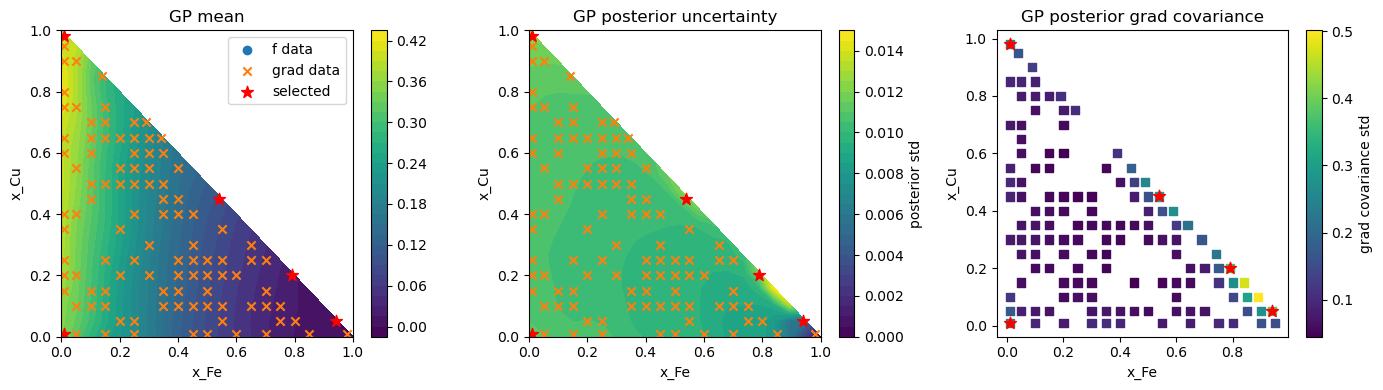

In [9]:
# X_star was made from xx, yy and then filtered by mask:
# X_star = X_star[X_star.sum(axis=1) <= 1]
mask = (xx.reshape(-1) + yy.reshape(-1)) <= 1.0


def triangular_grid(values, mask, shape):
    if not torch.is_tensor(values):
        values = torch.as_tensor(values)

    values = values.reshape(-1)
    mask = mask.to(device=values.device)

    n_tri = int(mask.sum().item())
    n_full = int(mask.numel())

    if values.numel() == n_tri:
        Z = torch.full(
            (n_full,),
            float("nan"),
            dtype=values.dtype,
            device=values.device,
        )
        Z[mask] = values
        return Z.reshape(shape).detach().cpu()

    if values.numel() == n_full:
        return values.reshape(shape).detach().cpu()

    raise ValueError(
        f"Cannot map {values.numel()} values onto grid: "
        f"expected either {n_tri} triangular points or {n_full} full-grid points."
    )


def to_numpy_xy(X):
    if X is None:
        return None

    if hasattr(X, "to_numpy"):
        X = X.to_numpy(dtype=float)

    if torch.is_tensor(X):
        X = X.detach().cpu().numpy()

    return X

species_now = 'Fe'
mean = gp_result_dict[species_now]['mean']
cov = gp_result_dict[species_now]['cov']


Z_mean = triangular_grid(mean, mask, xx.shape)

std = torch.sqrt(torch.clamp(torch.diag(cov), min=0.0))
Z_std = triangular_grid(std, mask, xx.shape)

xx_plot = xx.detach().cpu() if torch.is_tensor(xx) else xx
yy_plot = yy.detach().cpu() if torch.is_tensor(yy) else yy

X_f_plot = to_numpy_xy(X_f)
X_g_plot = to_numpy_xy(X_g)
X_selected_plot = to_numpy_xy(globals().get("X_selected", None))
X_unused_plot = to_numpy_xy(globals().get("X_unused", None))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- GP mean ---
cf0 = axes[0].contourf(xx_plot, yy_plot, Z_mean, levels=30)

if X_f_plot is not None:
    axes[0].scatter(X_f_plot[:, 0], X_f_plot[:, 1], marker="o", label="f data")

if X_g_plot is not None:
    axes[0].scatter(X_g_plot[:, 0], X_g_plot[:, 1], marker="x", label="grad data")

if X_selected_plot is not None:
    axes[0].scatter(
        X_selected_plot[:, 0],
        X_selected_plot[:, 1],
        c="r",
        marker="*",
        s=80,
        label="selected",
    )

fig.colorbar(cf0, ax=axes[0])
axes[0].set_title("GP mean")
axes[0].set_xlabel("x_Fe")
axes[0].set_ylabel("x_Cu")

# --- GP uncertainty ---
cf1 = axes[1].contourf(xx_plot, yy_plot, Z_std, levels=30)

if X_f_plot is not None:
    axes[1].scatter(X_f_plot[:, 0], X_f_plot[:, 1], marker="o")

if X_g_plot is not None:
    axes[1].scatter(X_g_plot[:, 0], X_g_plot[:, 1], marker="x")

if X_selected_plot is not None:
    axes[1].scatter(
        X_selected_plot[:, 0],
        X_selected_plot[:, 1],
        c="r",
        marker="*",
        s=80,
    )

fig.colorbar(cf1, ax=axes[1], label="posterior std")
axes[1].set_title("GP posterior uncertainty")
axes[1].set_xlabel("x_Fe")
axes[1].set_ylabel("x_Cu")

# --- Grad covariance ---
grad_std = torch.sqrt(torch.clamp(torch.diag(K_point), min=0.0)).detach().cpu()

if grad_std.numel() in (int(mask.sum().item()), mask.numel()):
    Z_grad_std = triangular_grid(grad_std, mask, xx.shape)
    cf2 = axes[2].contourf(xx_plot, yy_plot, Z_grad_std, levels=30)
    fig.colorbar(cf2, ax=axes[2], label="grad covariance std")
else:
    if X_unused_plot is None:
        raise ValueError(
            "K_point does not match the prediction grid, so provide X_unused "
            "with the same number of rows as diag(K_point)."
        )

    if len(X_unused_plot) != grad_std.numel():
        raise ValueError(
            f"X_unused has {len(X_unused_plot)} rows, but diag(K_point) has "
            f"{grad_std.numel()} entries."
        )

    sc2 = axes[2].scatter(
        X_unused_plot[:, 0],
        X_unused_plot[:, 1],
        c=grad_std.numpy(),
        cmap="viridis",
        marker="s",
        s=35,
    )
    fig.colorbar(sc2, ax=axes[2], label="grad covariance std")

if X_selected_plot is not None:
    axes[2].scatter(
        X_selected_plot[:, 0],
        X_selected_plot[:, 1],
        c="r",
        marker="*",
        s=80,
        label="selected",
    )

axes[2].set_title("GP posterior grad covariance")
axes[2].set_xlabel("x_Fe")
axes[2].set_ylabel("x_Cu")

axes[0].legend()
plt.tight_layout()
plt.show()